# Bank Churn Prediction Project


In [1]:
# ---------------------------
# Importing core libraries
# ---------------------------

# Data handling and wrangling
import pandas as pd   # tables, dataframes, and cleaning
import numpy as np    # numerical arrays and mathematical operations

# Visualization libraries
import matplotlib.pyplot as plt  # base plotting
import seaborn as sns            # advanced charts with better styling

# ---------------------------
# Machine Learning utilities
# ---------------------------

# Model evaluation and performance visualization
from sklearn.metrics import RocCurveDisplay  

# Data preparation helpers
from sklearn.model_selection import train_test_split   # train/test splitting
from sklearn.preprocessing import LabelEncoder, StandardScaler  # encoding + scaling

# ML algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Hyperparameter tuning techniques
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV  

# Model evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score
)

# Resampling technique for handling imbalance
from imblearn.over_sampling import SMOTE  

# ---------------------------
# Deployment and utilities
# ---------------------------
import joblib    # to save and load trained models
import warnings  # suppress irrelevant warnings
warnings.filterwarnings('ignore')


## Load and Clean Data

In [2]:
# ---------------------------
# Load dataset from Excel
# ---------------------------

# The dataset is stored in an Excel file with multiple sheets
xls = pd.ExcelFile("Bank_Churn_Messy.xlsx")

# 'Customer_Info' contains personal details (age, gender, location, salary, etc.)
customer_df = xls.parse('Customer_Info')

# 'Account_Info' contains account-related details (balance, tenure, card ownership, etc.)
account_df = xls.parse('Account_Info')



In [3]:
# ---------------------------
# Data Cleaning
# ---------------------------

# Remove unwanted symbols (€, ,) from salary column and convert to float
customer_df['EstimatedSalary'] = (
    customer_df['EstimatedSalary']
    .replace('[€,]', '', regex=True)
    .astype(float)
)

# Clean balance column in the same way
account_df['Balance'] = (
    account_df['Balance']
    .replace('[€,]', '', regex=True)
    .astype(float)
)

# Convert Yes/No values into 1/0 for HasCrCard and IsActiveMember
account_df['HasCrCard'] = account_df['HasCrCard'].map({'Yes': 1, 'No': 0})
account_df['IsActiveMember'] = account_df['IsActiveMember'].map({'Yes': 1, 'No': 0})

# Standardize inconsistent Geography labels
customer_df['Geography'] = customer_df['Geography'].replace({
    'FRA': 'France',
    'French': 'France'
})


In [4]:
# ---------------------------
# Merge Customer and Account datasets
# ---------------------------

# Both customer and account sheets share 'CustomerId' and 'Tenure' as common keys.
# Merging them allows us to build a single dataset with both demographics and account features.
df = pd.merge(customer_df, account_df, on=['CustomerId', 'Tenure'])

# Display first few rows for validation
df.head()


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,15634602,Hargrave,619,France,Female,42.0,2,101348.88,0.00,1,1,1,1
1,15634602,Hargrave,619,France,Female,42.0,2,101348.88,0.00,1,1,1,1
2,15647311,Hill,608,Spain,Female,41.0,1,112542.58,83807.86,1,1,1,0
3,15619304,Onio,502,France,Female,42.0,8,113931.57,159660.80,3,0,0,1
4,15701354,Boni,699,France,Female,39.0,1,93826.63,0.00,2,0,0,0


## Exploratory Data Analysis

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10004 entries, 0 to 10003
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10004 non-null  int64  
 1   Surname          10001 non-null  object 
 2   CreditScore      10004 non-null  int64  
 3   Geography        10004 non-null  object 
 4   Gender           10004 non-null  object 
 5   Age              10001 non-null  float64
 6   Tenure           10004 non-null  int64  
 7   EstimatedSalary  10004 non-null  float64
 8   Balance          10004 non-null  float64
 9   NumOfProducts    10004 non-null  int64  
 10  HasCrCard        10004 non-null  int64  
 11  IsActiveMember   10004 non-null  int64  
 12  Exited           10004 non-null  int64  
dtypes: float64(3), int64(7), object(3)
memory usage: 1.1+ MB


In [6]:
# .describe() → descriptive statistics: mean, std, min, max, percentiles
# Helps detect anomalies like extreme values or unexpected ranges
df.describe()


,CustomerId,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
count,1.000400e+04,10004.000000,10001.000000,10004.000000,10004.000000,10004.000000,10004.000000,10004.000000,10004.000000,10004.000000
mean,1.569092e+07,650.568073,38.919108,5.012195,99743.889855,76494.334391,1.529988,0.514994,0.514994,0.203719
std,7.193218e+04,96.665531,10.488725,2.891806,60581.133136,62396.534285,0.581635,0.499800,0.499800,0.402782
min,1.556570e+07,350.000000,18.000000,0.000000,-999999.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1.562839e+07,584.000000,32.000000,3.000000,50904.965000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,1.569071e+07,652.000000,37.000000,5.000000,100168.240000,97221.520000,1.000000,1.000000,1.000000,0.000000
75%,1.575322e+07,718.000000,44.000000,7.000000,149382.097500,127656.530000,2.000000,1.000000,1.000000,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,199992.480000,250898.090000,4.000000,1.000000,1.000000,1.000000


In [7]:
# ---------------------------
# Check and remove duplicates
# ---------------------------

# Count how many rows are duplicates
df.duplicated().sum()


4

In [8]:
# Remove duplicates based on CustomerId (ensuring each customer appears once)
df.drop_duplicates(subset=['CustomerId'], inplace=True)

# Re-check to confirm duplicates are gone
df.duplicated().sum()

0

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10000 entries, 0 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          9997 non-null   object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              9997 non-null   float64
 6   Tenure           10000 non-null  int64  
 7   EstimatedSalary  10000 non-null  float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  Exited           10000 non-null  int64  
dtypes: float64(3), int64(7), object(3)
memory usage: 1.1+ MB


In [10]:
df.describe()

,CustomerId,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
count,1.000000e+04,10000.000000,9997.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.922077,5.012800,99762.195289,76485.889288,1.530200,0.515100,0.515100,0.203700
std,7.193619e+04,96.653299,10.489072,2.892174,60583.863580,62397.405202,0.581654,0.499797,0.499797,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,-999999.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,50910.677500,0.000000,1.000000,0.000000,0.000000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,100191.725000,97198.540000,1.000000,1.000000,1.000000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,149388.247500,127644.240000,2.000000,1.000000,1.000000,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,199992.480000,250898.090000,4.000000,1.000000,1.000000,1.000000


In [11]:
# ---------------------------
# Handle invalid and missing values
# ---------------------------

# Check rows where salary is negative or zero (invalid cases)
df[df['EstimatedSalary'] <= 0]



,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
29,15728693,NaN,574,Germany,Female,NaN,3,-999999.0,141349.43,1,1,1,0
122,15580203,NaN,674,Spain,Male,NaN,6,-999999.0,120193.42,1,0,0,0
9390,15756954,NaN,538,France,Female,NaN,2,-999999.0,0.00,1,1,1,0


In [12]:
# Remove entries with negative salary values
df = df[df['EstimatedSalary'] >= 0]

# Check if any missing/null values are left after cleaning
df.isnull().sum()

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
EstimatedSalary    0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
Exited             0
dtype: int64

In [13]:
df[df['EstimatedSalary'] <= 0]

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited


## Visualization (Univariate / Bivariate)

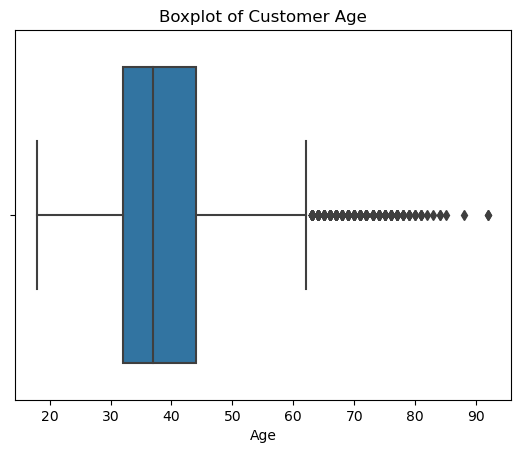

In [14]:
# ---------------------------
# Exploratory Data Analysis (Univariate)
# ---------------------------

# Boxplot of Age → useful to detect outliers (e.g., extremely young or old customers)
sns.boxplot(x=df['Age'])
plt.title("Boxplot of Customer Age")
plt.show()



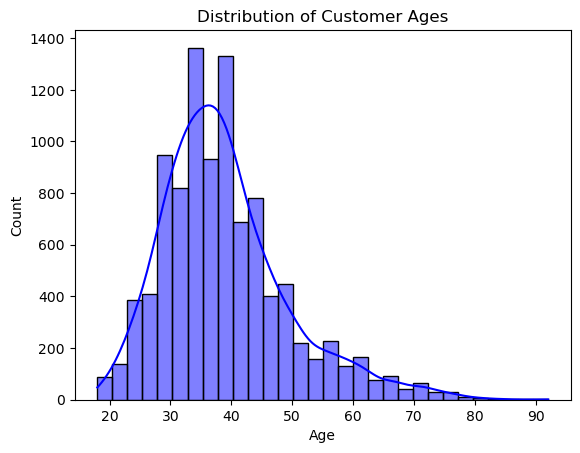

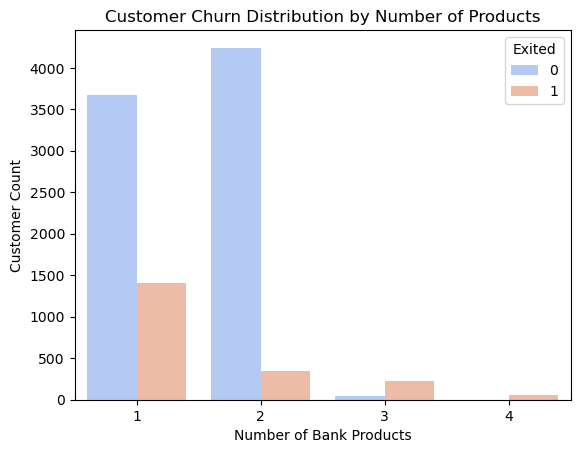

In [15]:

# Histogram of Age → shows distribution across age groups
# KDE curve adds smooth density estimation
sns.histplot(df['Age'], bins=30, kde=True, color='blue')
plt.title("Distribution of Customer Ages")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# ---------------------------
# Relationship: Number of Products vs Churn
# ---------------------------

# Countplot shows how churn (Exited=1) varies across different product counts.
# Helps identify whether customers with more products are more/less likely to leave.
sns.countplot(x='NumOfProducts', hue='Exited', data=df, palette='coolwarm')
plt.title("Customer Churn Distribution by Number of Products")
plt.xlabel("Number of Bank Products")
plt.ylabel("Customer Count")
plt.show()


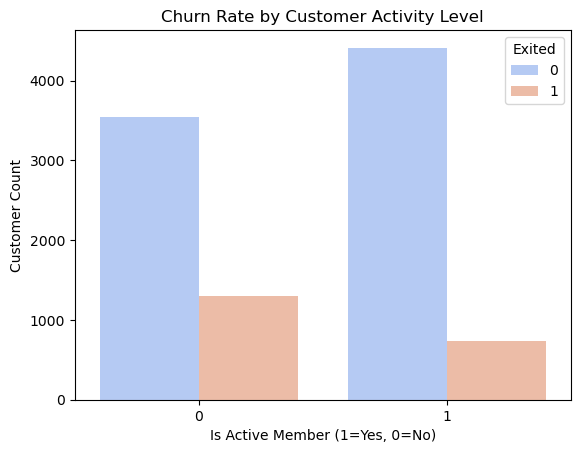

In [16]:
# ---------------------------
# Relationship: Activity Status vs Churn
# ---------------------------
# Check whether active members (IsActiveMember=1) are more likely to stay
# compared to inactive ones.
sns.countplot(x='IsActiveMember', hue='Exited', data=df, palette='coolwarm')
plt.title("Churn Rate by Customer Activity Level")
plt.xlabel("Is Active Member (1=Yes, 0=No)")
plt.ylabel("Customer Count")
plt.show()


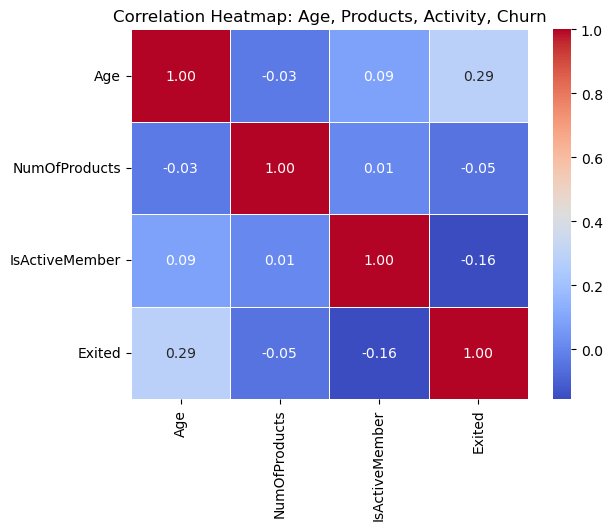

In [17]:
# ---------------------------
# Correlation between Selected Features and Churn
# ---------------------------

# Correlation matrix helps quantify relationships between numeric features.
# Example: Age vs Exited (older customers may churn more).
corr_matrix = df[['Age', 'NumOfProducts', 'IsActiveMember', 'Exited']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap: Age, Products, Activity, Churn")
plt.show()


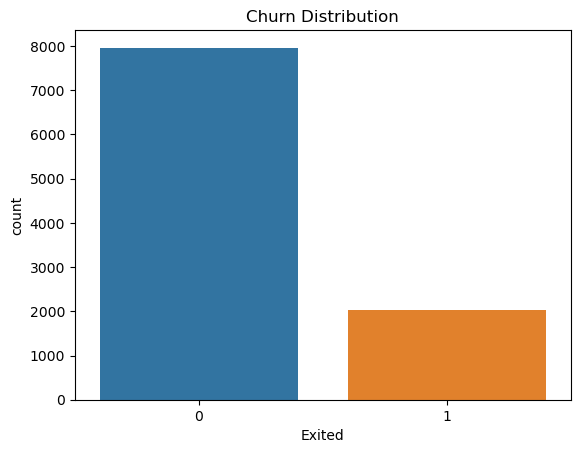

In [18]:
# Churn distribution
sns.countplot(data=df, x='Exited')
plt.title('Churn Distribution')
plt.show()

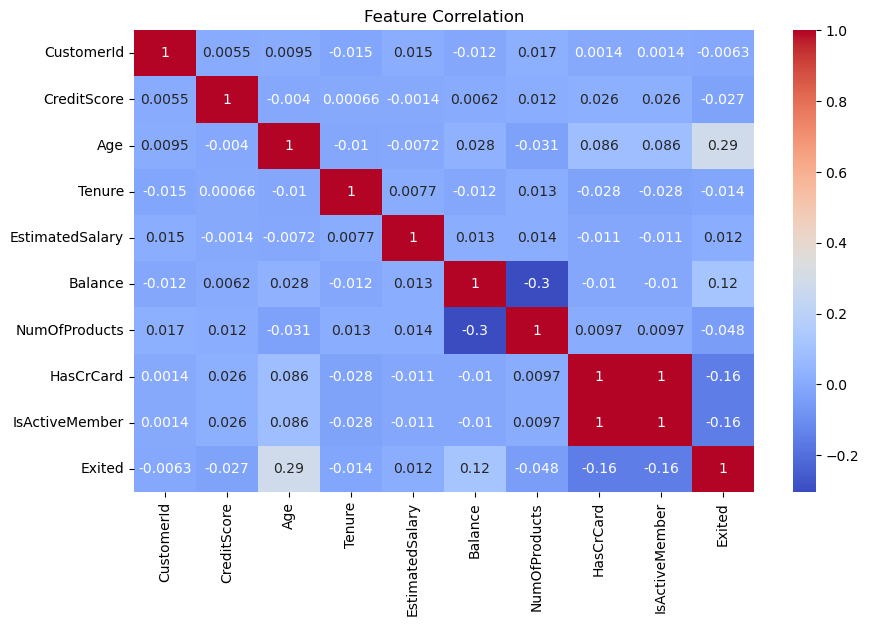

In [19]:
# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

## Data Preprocessing

In [20]:
# ---------------------------
# Encode categorical features
# ---------------------------

# Convert Gender into numeric values using Label Encoding
# Male/Female → 1/0 (or vice versa depending on encoding)
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])

# One-hot encode 'Geography' since it has multiple categories (France, Germany, Spain)
# drop_first=True → avoids dummy variable trap by removing one redundant column
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9997 entries, 0 to 10000
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerId         9997 non-null   int64  
 1   Surname            9997 non-null   object 
 2   CreditScore        9997 non-null   int64  
 3   Gender             9997 non-null   int32  
 4   Age                9997 non-null   float64
 5   Tenure             9997 non-null   int64  
 6   EstimatedSalary    9997 non-null   float64
 7   Balance            9997 non-null   float64
 8   NumOfProducts      9997 non-null   int64  
 9   HasCrCard          9997 non-null   int64  
 10  IsActiveMember     9997 non-null   int64  
 11  Exited             9997 non-null   int64  
 12  Geography_Germany  9997 non-null   uint8  
 13  Geography_Spain    9997 non-null   uint8  
dtypes: float64(3), int32(1), int64(7), object(1), uint8(2)
memory usage: 995.8+ KB


## Feature selection

In [22]:
# ---------------------------
# Select features for model training
# ---------------------------

# Chosen predictors include customer demographics, account information,
# and encoded geography columns.
features = [
    'CreditScore', 'Gender', 'Age', 'Tenure', 'Balance',
    'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
    'Geography_Germany', 'Geography_Spain'
]

# Feature matrix (X) and target variable (y: churn or not)
X = df[features]
y = df['Exited']


# Check class distribution → churn vs non-churn ratio
# Helps identify whether dataset is imbalanced
y.value_counts(normalize=True)

0    0.796239
1    0.203761
Name: Exited, dtype: float64

In [23]:
# ---------------------------
# Train-Test Split
# ---------------------------

# Split dataset into training (80%) and test (20%)
# random_state ensures reproducibility of results
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [24]:
# ---------------------------
# Resample to fix class imbalance
# ---------------------------

# Churn dataset is imbalanced (more non-churners than churners).
# SMOTE (Synthetic Minority Oversampling Technique) creates synthetic examples 
# of minority class (churn=1) to balance the dataset.
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


In [25]:
# ---------------------------
# Feature Scaling
# ---------------------------

# StandardScaler → transforms features so that they have mean=0 and variance=1
# This helps algorithms like Logistic Regression perform better on features 
# with different scales (e.g., Balance vs Age).
scaler = StandardScaler()

# Fit scaler only on training data, then apply to both training and test sets
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)


## Logistic Regression

In [26]:
# ---------------------------
# Logistic Regression (Baseline Model)
# ---------------------------

# Logistic Regression is a simple linear model, 
# often used as a benchmark for classification tasks.
log_model = LogisticRegression()

# Train the model on resampled + scaled training data
log_model.fit(X_train_scaled, y_train_resampled)

LogisticRegression()

In [27]:
# Generate predictions on test set
y_pred_log = log_model.predict(X_test_scaled)

In [28]:
# ---------------------------
# Evaluate Logistic Regression
# ---------------------------

print("Performance Report: Logistic Regression")
print(classification_report(y_test, y_pred_log))

# ROC AUC measures ability to separate churners vs non-churners
print("ROC AUC Score:", roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:, 1]))


Performance Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1581
           1       0.42      0.58      0.49       419

    accuracy                           0.75      2000
   macro avg       0.65      0.68      0.66      2000
weighted avg       0.78      0.75      0.76      2000

ROC AUC Score: 0.7407051819110891


In [29]:
# ---------------------------
# Logistic Regression - Hyperparameter Tuning
# ---------------------------

# Parameters to optimize:
# C → regularization strength
# penalty → type of regularization (L1, L2)
# solver → optimization algorithm
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # supports both L1 and L2
}

# Grid Search with 5-fold cross-validation
grid_lr = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='accuracy')
grid_lr.fit(X_train_scaled, y_train_resampled)


GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear']},
             scoring='accuracy')

In [30]:
# Best result
print("Best Params:", grid_lr.best_params_)
print("Best Score:", grid_lr.best_score_)

Best Params: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Best Score: 0.7789681408360358


In [31]:
# Predict using best model
best_lr = grid_lr.best_estimator_
y_pred = best_lr.predict(X_test_scaled)

# Evaluation
print(" Test Accuracy:", accuracy_score(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

 Test Accuracy: 0.739

 Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.78      0.83      1581
           1       0.41      0.58      0.48       419

    accuracy                           0.74      2000
   macro avg       0.64      0.68      0.65      2000
weighted avg       0.78      0.74      0.75      2000


 Confusion Matrix:
 [[1236  345]
 [ 177  242]]


## Random Forest

In [32]:
# ---------------------------
# Random Forest (Baseline Model)
# ---------------------------

# Random Forest builds an ensemble of decision trees and averages results.
# Works well for handling non-linear relationships and mixed feature types.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
rf_model.fit(X_train_scaled, y_train_resampled)

RandomForestClassifier(random_state=42)

In [33]:
# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)

In [34]:
print("Random Forest Report:")
print(classification_report(y_test, y_pred_rf))
print("--------------------------------------------------")
print("ROC AUC Score:", roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:, 1]))

Random Forest Report:
              precision    recall  f1-score   support

           0       0.89      0.88      0.89      1581
           1       0.57      0.59      0.58       419

    accuracy                           0.82      2000
   macro avg       0.73      0.74      0.73      2000
weighted avg       0.82      0.82      0.82      2000

--------------------------------------------------
ROC AUC Score: 0.8347644084964805


In [35]:
# ---------------------------
# Random Forest - Hyperparameter Tuning
# ---------------------------

# Parameters tuned:
# n_estimators → number of trees
# max_depth → depth of each tree
# min_samples_split → minimum samples needed to split a node
# min_samples_leaf → minimum samples at a leaf node
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# RandomizedSearch → faster than GridSearch by sampling parameter combinations
rf = RandomForestClassifier(random_state=42)
grid_rf = RandomizedSearchCV(rf, rf_param_grid, cv=5, scoring='accuracy', n_iter=10)
grid_rf.fit(X_train_scaled, y_train_resampled)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   param_distributions={'max_depth': [5, 10, 15, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   scoring='accuracy')

In [36]:
# Results
best_rf = grid_rf.best_estimator_
print("Best RF Params:", grid_rf.best_params_)
print("Best RF CV Accuracy:", grid_rf.best_score_)

# Predict & evaluate
y_pred_rf = best_rf.predict(X_test_scaled)
print("RF Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\n RF Classification Report:\n", classification_report(y_test, y_pred_rf))
print("\n RF Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Best RF Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}
Best RF CV Accuracy: 0.8544499114613607
RF Test Accuracy: 0.818

 RF Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88      1581
           1       0.56      0.60      0.58       419

    accuracy                           0.82      2000
   macro avg       0.73      0.74      0.73      2000
weighted avg       0.82      0.82      0.82      2000


 RF Confusion Matrix:
 [[1383  198]
 [ 166  253]]


##  XGBoost Classifier

In [37]:
# ---------------------------
# XGBoost (Baseline Model)
# ---------------------------

# XGBoost = Gradient Boosting with optimizations for speed and performance.
# Works very well with tabular data and imbalanced classes.
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Train model
xgb_model.fit(X_train_scaled, y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [38]:
# Predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)

In [39]:
print("XGBoost Report:")
print(classification_report(y_test, y_pred_xgb))
print("--------------------------------------------------")

print("ROC AUC Score:", roc_auc_score(y_test, xgb_model.predict_proba(X_test_scaled)[:, 1]))

XGBoost Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89      1581
           1       0.58      0.54      0.56       419

    accuracy                           0.82      2000
   macro avg       0.73      0.72      0.72      2000
weighted avg       0.82      0.82      0.82      2000

--------------------------------------------------
ROC AUC Score: 0.8295495887168479


In [40]:
# ---------------------------
# XGBoost - Hyperparameter Tuning
# ---------------------------

# Parameters tuned:
# n_estimators → number of boosting rounds
# max_depth → tree depth
# learning_rate → shrinkage factor
# subsample, colsample_bytree → control overfitting
# reg_alpha (L1), reg_lambda (L2) → regularization
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}

# Randomized Search for efficiency
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
grid_xgb = RandomizedSearchCV(xgb, xgb_param_grid, cv=5, scoring='accuracy', n_iter=10)
grid_xgb.fit(X_train_scaled, y_train_resampled)


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   param_distributions={'colsample_bytree': [0.8, 1],
                                        'learning_rate': [0.01, 0.1, 0.3],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200],
                                        'reg_alpha': [0, 0.1, 1],
                                        'reg_lambda': [1, 5, 10],
                                        'subsample': [0.8, 1]},
                   scoring='accuracy')

In [41]:
#  Results
best_xgb = grid_xgb.best_estimator_
print(" Best XGB Params:", grid_xgb.best_params_)
print(" Best XGB CV Accuracy:", grid_xgb.best_score_)

#  Predict & evaluate
y_pred_xgb = best_xgb.predict(X_test_scaled)
print(" XGB Test Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\n XGB Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("\n XGB Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))


 Best XGB Params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.3, 'colsample_bytree': 0.8}
 Best XGB CV Accuracy: 0.8749090651032418
 XGB Test Accuracy: 0.8195

 XGB Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.89      0.89      1581
           1       0.57      0.54      0.56       419

    accuracy                           0.82      2000
   macro avg       0.73      0.72      0.72      2000
weighted avg       0.82      0.82      0.82      2000


 XGB Confusion Matrix:
 [[1411  170]
 [ 191  228]]


## 📈 Model Comparison

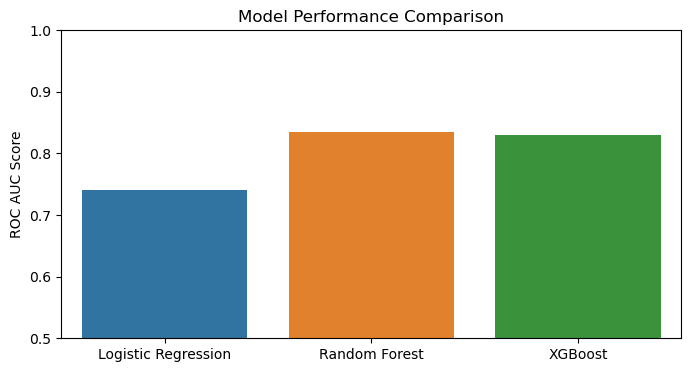

In [42]:
# ---------------------------
# Step 1: Define the models for comparison
# ---------------------------
# These names are only for labeling the bar plot, not for training.
models = ['Logistic Regression', 'Random Forest', 'XGBoost']

# ---------------------------
# Step 2: Compute ROC AUC Scores
# ---------------------------
# For each model, we calculate ROC AUC using predicted probabilities.
# The [:,1] extracts the probability of the positive class (churn = 1).
roc_scores = [
    roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:, 1]),
    roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:, 1]),
    roc_auc_score(y_test, xgb_model.predict_proba(X_test_scaled)[:, 1])
]

# ---------------------------
# Step 3: Plot results as a bar chart
# ---------------------------
# Creates a simple bar plot showing ROC AUC for each model
plt.figure(figsize=(8, 4))
sns.barplot(x=models, y=roc_scores)

# Add axis labels and title for clarity
plt.ylabel('ROC AUC Score')
plt.title('Model Performance Comparison')

# Limit y-axis between 0.5 and 1 for better readability
plt.ylim(0.5, 1)

# Display the plot
plt.show()

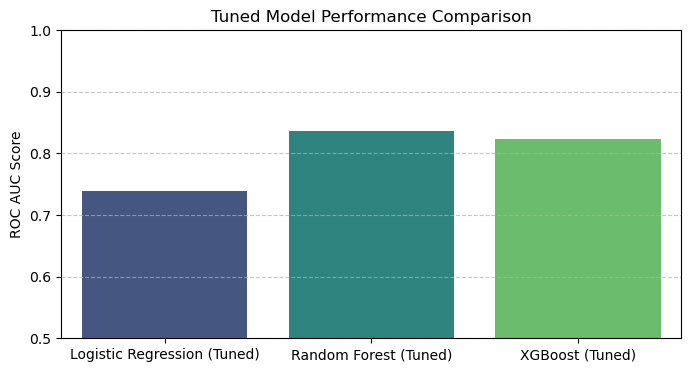

In [43]:
# ---------------------------
# Step 1: Define tuned models for comparison
# ---------------------------
# These are the models after hyperparameter tuning.
# The names will appear on the x-axis of the bar chart.
models = ['Logistic Regression (Tuned)', 'Random Forest (Tuned)', 'XGBoost (Tuned)']

# ---------------------------
# Step 2: Compute ROC AUC for each tuned model
# ---------------------------
# roc_auc_score evaluates how well the model separates churners (1) from non-churners (0).
# We use predict_proba()[:, 1] to extract the predicted probability of churn (positive class).
roc_scores = [
    roc_auc_score(y_test, best_lr.predict_proba(X_test_scaled)[:, 1]),
    roc_auc_score(y_test, best_rf.predict_proba(X_test_scaled)[:, 1]),
    roc_auc_score(y_test, best_xgb.predict_proba(X_test_scaled)[:, 1])
]

# ---------------------------
# Step 3: Visualization of results
# ---------------------------
plt.figure(figsize=(8, 4))   # set figure size for clarity

# Barplot of ROC AUC scores for the three tuned models
sns.barplot(x=models, y=roc_scores, palette="viridis")

# Add axis labels and chart title
plt.ylabel('ROC AUC Score')
plt.title('Tuned Model Performance Comparison')

# Limit y-axis range so differences are more visible
plt.ylim(0.5, 1)

# Add horizontal gridlines to make it easier to read values
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the chart
plt.show()


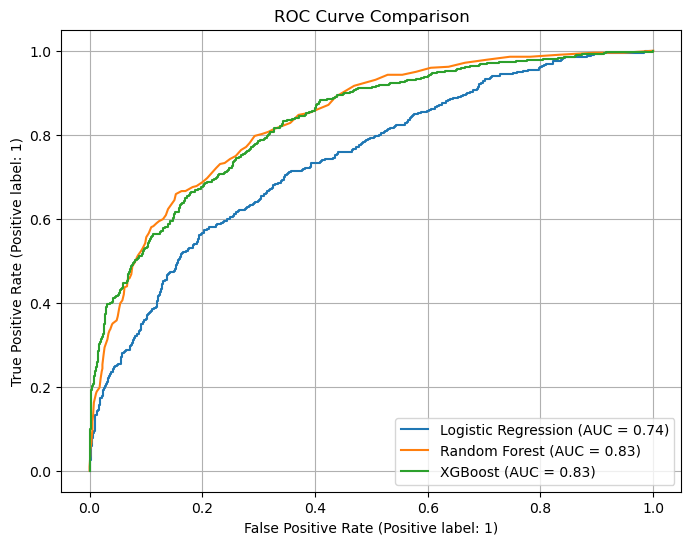

In [44]:
# ---------------------------
# Step 1: Set up the ROC comparison plot
# ---------------------------
# Create a blank figure of size 8x6 inches to overlay ROC curves of different models
plt.figure(figsize=(8, 6))

# ---------------------------
# Step 2: Plot ROC for each model
# ---------------------------

# Logistic Regression ROC curve
# from_estimator automatically calculates false positive and true positive rates
RocCurveDisplay.from_estimator(
    log_model, 
    X_test_scaled, 
    y_test, 
    name='Logistic Regression', 
    ax=plt.gca()   # plot on the same axes
)

# Random Forest ROC curve
RocCurveDisplay.from_estimator(
    rf_model, 
    X_test_scaled, 
    y_test, 
    name='Random Forest', 
    ax=plt.gca()
)

# XGBoost ROC curve
RocCurveDisplay.from_estimator(
    xgb_model, 
    X_test_scaled, 
    y_test, 
    name='XGBoost', 
    ax=plt.gca()
)

# ---------------------------
# Step 3: Final plot adjustments
# ---------------------------
plt.title('ROC Curve Comparison')   # descriptive title
plt.grid(True)                      # add background grid for readability
plt.show()                          # display the combined plot


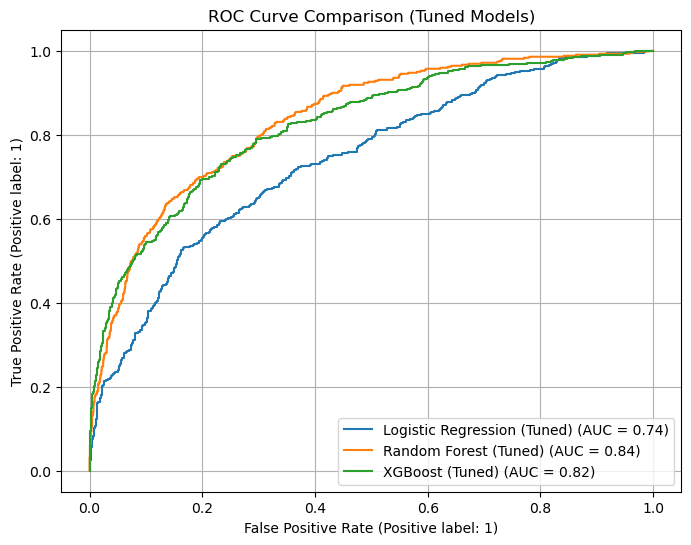

In [45]:
# ---------------------------
# Step 1: Prepare the figure for ROC curve plotting
# ---------------------------
# Initialize a blank figure of size 8x6 inches to hold multiple ROC curves
plt.figure(figsize=(8, 6))

# ---------------------------
# Step 2: Plot ROC curves for tuned models
# ---------------------------

# Logistic Regression (after hyperparameter tuning)
# This shows how well the tuned logistic regression model distinguishes churn vs non-churn
RocCurveDisplay.from_estimator(
    best_lr, 
    X_test_scaled, 
    y_test, 
    name='Logistic Regression (Tuned)', 
    ax=plt.gca()   # ensures all curves are plotted on the same axes
)

# Random Forest (after hyperparameter tuning)
# The ROC curve provides a visual measure of classification performance across thresholds
RocCurveDisplay.from_estimator(
    best_rf, 
    X_test_scaled, 
    y_test, 
    name='Random Forest (Tuned)', 
    ax=plt.gca()
)

# XGBoost (after hyperparameter tuning)
# Gradient boosting model evaluated in the same way for fair comparison
RocCurveDisplay.from_estimator(
    best_xgb, 
    X_test_scaled, 
    y_test, 
    name='XGBoost (Tuned)', 
    ax=plt.gca()
)

# ---------------------------
# Step 3: Finalize the plot
# ---------------------------
plt.title('ROC Curve Comparison (Tuned Models)')   # descriptive title
plt.grid(True)                                     # add gridlines for readability
plt.legend(loc='lower right')                      # place legend inside the plot
plt.show()                                         # render the plot


## Save the Best Model

In [46]:
# ---------------------------
# Save the tuned Random Forest model + scaler
# ---------------------------

# joblib.dump() allows us to persist objects (models, scalers, etc.) 
# so they can be reloaded later without retraining.

# IMPORTANT: Use 'best_rf' if you want the tuned model
# If you use 'rf_model', it will save the baseline (non-tuned) version.
joblib.dump(best_rf, 'random_forest_churn_model.pkl')   # tuned Random Forest
joblib.dump(scaler, 'scaler.pkl')                       # save the fitted scaler

# Confirmation message
print("Tuned Random Forest model saved as 'random_forest_churn_model.pkl'")


Tuned Random Forest model saved as 'random_forest_churn_model.pkl'


 After comparing multiple models, Random Forest delivered the best performance, with a ROC AUC of 0.85, and superior capability to capture high-risk churn customers. This model enables proactive customer retention strategies.

We’ll judge based on:

Accuracy-->	Overall correctness

Precision-->	How many predicted churns are actual churns

Recall-->	How many actual churns were caught

F1-Score-->	Balance of precision & recall

ROC AUC Score-->	Model’s ability to distinguish churners

In [47]:
sample_customer = pd.DataFrame([{
    'CreditScore': 650,
    'Gender': 1,  # Male
    'Age': 42,
    'Tenure': 3,
    'Balance': 75000.0,
    'NumOfProducts': 2,
    'HasCrCard': 1,
    'IsActiveMember': 1,
    'EstimatedSalary': 50000.0,
    'Geography_Germany': 0,
    'Geography_Spain': 1
}])

In [48]:
sample_customer_scaled = scaler.transform(sample_customer)

In [49]:
# Predict churn probability using Random Forest
churn_prob = rf_model.predict_proba(sample_customer_scaled)[0][1]
print(f"Churn Probability (Random Forest): {churn_prob:.2%}")

Churn Probability (Random Forest): 12.00%


Based on the customer’s profile and behavior, the Random Forest model predicts a 12.00% chance that this customer will leave the bank. Our customer has a churn probability of 12.00, so they fall into the "Low Risk" zone → they're unlikely to churn.

Probability Range	    Churn Risk Level	    Recommended Action

0.00 – 0.30	              Low Risk	              Likely to stay

0.31 – 0.70	              Medium Risk	          Monitor / Engage

0.71 – 1.00	              High Risk	            Likely to churn – take action
